<a href="https://colab.research.google.com/github/Sveshchaudhary/telco-customer-churn-analysis/blob/main/Telco_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [8]:
df['TotalCharges'].dtype

dtype('O')

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df = df.dropna(subset=['TotalCharges'])

In [12]:
df['TotalCharges'].isnull().sum()

np.int64(0)

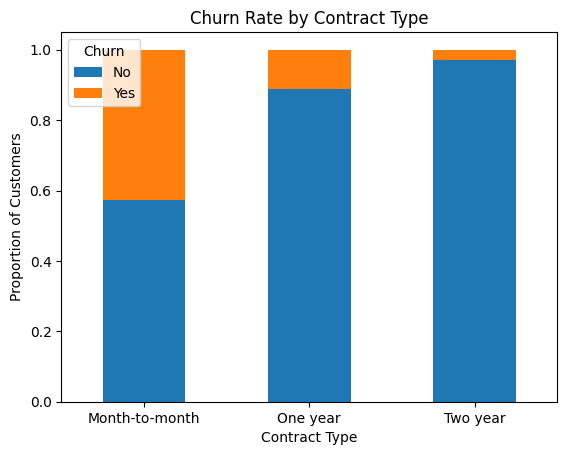

In [13]:

import matplotlib.pyplot as plt

df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion of Customers')
plt.xlabel('Contract Type')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.show()

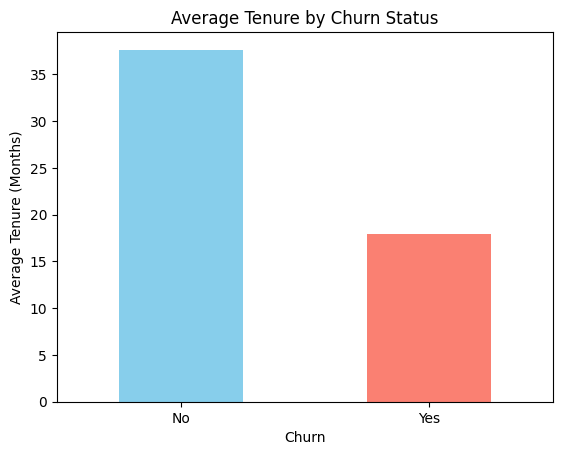

In [14]:

df.groupby('Churn')['tenure'].mean().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Tenure by Churn Status')
plt.ylabel('Average Tenure (Months)')
plt.xlabel('Churn')
plt.xticks(rotation=0)
plt.show()

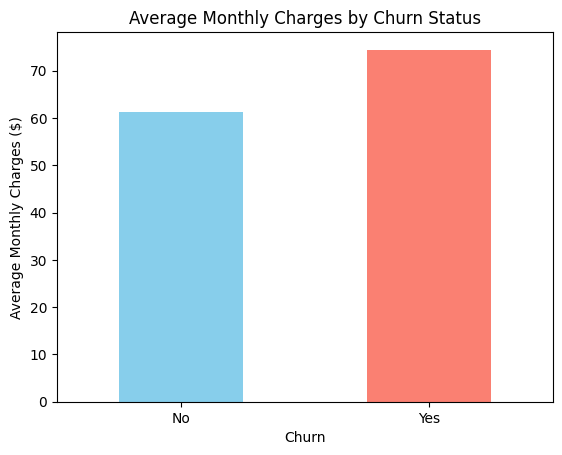

In [15]:
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Monthly Charges by Churn Status')
plt.ylabel('Average Monthly Charges ($)')
plt.xlabel('Churn')
plt.xticks(rotation=0)
plt.show()

## Summary of Findings

This analysis explored customer churn patterns in a telecom dataset of 7,043 customers.

- Overall churn rate: 26.5%
- Customers on month-to-month contracts churn at a much higher rate (approx. 42%) compared to one-year (approx. 12%) and two-year (approx. 3%) contracts, suggesting contract length is a strong retention factor.
- Churned customers had a much shorter average tenure (approx. 18 months) than retained customers (approx. 37 months), indicating churn risk is highest early in the customer relationship.
- Churned customers paid higher average monthly charges (approx. $74) than retained customers (approx. $61), suggesting price sensitivity may contribute to churn.

**Recommendation:** Focus retention efforts on new, month-to-month customers — consider incentives for longer-term contracts or loyalty discounts for high-paying customers in their first year.